# 460 — Functional-role matching (concatenated, conjunction)

The **condition-structured** path. Each contact is the three conditions stitched in time,
`[audio | picture | reading]`. We **discretize** to a clustering-exact −1/0/+1 map (the same
segmentation 02 uses — `CLUSTERING_SEG_KWARGS`, no score gate) and assign a
**functional role** only if the contact expresses **every** box of that role's conjunction
template (strict AND) — a box expresses its sign via the clustering **proportion gate** on the
−1/+1 cells. Roles live in `functions/roi_config_concatenated.py` (auditory / visual / motor /
multimodal — **draft, edit them**).

- **Auditory** = HGA in the audio **stimulus** + the **response** of all three (hears stimulus +
  hears own voice ×3). **Motor** = HGA in all three responses. **Visual** = HGA in the picture &
  reading stimuli. The discriminator is the *stimulus* boxes (response is shared motor/feedback —
  only **anatomy** separates those, which is what the POOL map shows).
- One sample per contact; **only contacts with all three conditions** enter.
- `role` = the **most specific** matching template (most boxes); `roles_matched` lists all.

> Discretization needs blob resolution, so `USE_DS=False` (full 129×300) is the faithful baseline;
> `USE_DS=True` downsamples the painted map (faster, coarser).


In [8]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import display, Markdown, Image
sys.path.insert(0, str(Path('..').resolve()))
from functions import lf_pool as P

INPUT_DIR = Path(r'\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY')
if not INPUT_DIR.exists():
    INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY').resolve()

print('INPUT_DIR :', INPUT_DIR, '| exists:', INPUT_DIR.exists())
print('OUTPUTS   :', P.OUTPUTS_ROOT)
print('COORDS    :', P.COORDS_DIR, '| exists:', P.COORDS_DIR.exists())
print('conditions:', P.CONDITIONS, '| zones:', P.DEFAULT_ZONES)
print('feature sets:', P.FEATURE_SETS, '| window shapes:', P.WINDOW_SHAPES)


INPUT_DIR : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY | exists: True
OUTPUTS   : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling
COORDS    : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\250_recon\fsaverage\coords | exists: True
conditions: ('audio', 'picture', 'reading') | zones: ('perception', 'pre_articulation', 'audio')
feature sets: ('hg', 'bands15') | window shapes: ('boxcar', 'gaussian')


In [9]:
# ---- knobs ----
USE_DS    = False                    # False: full-res discretized baseline (recommended) · True: ds
GRID      = 'ds' if USE_DS else 'full'
print('grid:', GRID, '| roles:', [r['role'] for r in P.ROLE_PARAMS[GRID]['roles']])


grid: full | roles: ['auditory', 'visual_picture', 'visual_reading', 'lexical_semantic', 'heteromodal_convergence', 'maintenance', 'phonological_encoding', 'motor', 'auditory_feedback', 'deactivation', 'tag_hga_activation', 'tag_beta_erd', 'tag_low_f_erd', 'tag_theta_tracking', 'ultra_hfa', 'stimulus_responsive', 'response_active']


## 1 — Load dataset (clustering-exact discretization, no score gate)


In [10]:
df_meta, X_full = P.prepare_pooling_dataset(INPUT_DIR)
score_min = None        # clustering-exact: the 231 minus101 maps used score_min=None
print('score gate:', score_min, '| seg:', P.CLUSTERING_SEG_KWARGS)


[lf_dataset cache hit] \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\_dataset\pooling\_raw_ungated
  8841 samples · X_3d.shape=(8841, 129, 300)
[lf_pool] 8841 samples, 8841 with a contact key, X_3d=(8841, 129, 300)
score gate: None | seg: {'thr_pos': 2.5, 'thr_neg': -3.5, 'delta_valley': 1.5, 'min_mean_pos': 1.75, 'max_mean_neg': -2.8000000000000003, 'max_blobs': 6}


## 2 — Concatenate + discretize (clustering-exact; one map per all-3-condition contact)


In [11]:
df_contacts, X_disc = P.build_concat_discretized(df_meta, X_full, score_min=score_min, grid=GRID, seg_kwargs=P.CLUSTERING_SEG_KWARGS)
print('contacts:', len(df_contacts), '| X_disc:', X_disc.shape)
df_contacts.head()


[lf_pool] concat-discretized: 2856 contacts with all 3 conditions · X_disc=(2856, 129, 900)
contacts: 2856 | X_disc: (2856, 129, 900)


,patient_id,contact_norm,electrode
0,EL030,AL10,A_L10
1,EL030,AL11,A_L11
2,EL030,AL12,A_L12
3,EL030,AL13,A_L13
4,EL030,AL14,A_L14


## 3 — Conjunction role matching
A contact gets a role only if **all** that role's boxes clear the proportion gate in the expected
sign. `role` = most-specific match.


[lf_pool] roles run -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\roles\full\runs\20260625_124047
[lf_pool] role table: (2856, 7)


,role,n_matched,n_primary
0,tag_theta_tracking,653,457
1,tag_hga_activation,582,565
2,response_active,485,0
3,tag_low_f_erd,299,134
4,ultra_hfa,264,51
5,tag_beta_erd,261,194
6,stimulus_responsive,193,0
7,phonological_encoding,55,0
8,visual_picture,44,1
9,visual_reading,30,1


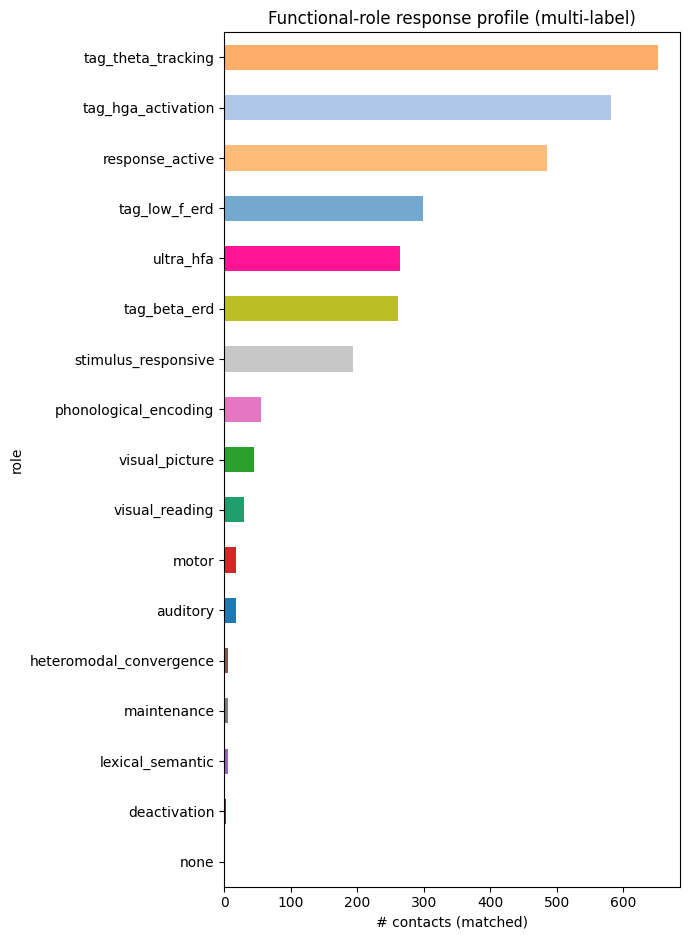

In [12]:
import matplotlib.pyplot as plt
df_role = P.build_role_table(df_contacts, X_disc, grid=GRID)
counts = P.role_counts(df_role)
display(counts)
# role_counts is multi-label: n_matched = contacts where the role is in roles_matched
# (a contact counts toward every role it shows); n_primary = most-specific winner.
ax = counts.set_index('role')['n_matched'].plot.barh(figsize=(7, 0.5 * len(counts) + 1),
        color=[P.role_colors(GRID).get(r, '#888') for r in counts['role']])
ax.set_xlabel('# contacts (matched)'); ax.set_title('Functional-role response profile (multi-label)')
ax.invert_yaxis(); plt.tight_layout(); plt.show()


## 3b — Role co-occurrence (multi-label overlap)
How often each pair of roles is matched by the **same** contact (via `roles_matched`).
The **diagonal** = total contacts matching that role; **off-diagonal** = the size of each
pairwise intersection — the "Venn" view across all roles at once (e.g. how many contacts
are *both* `auditory` and `auditory_suppression`).


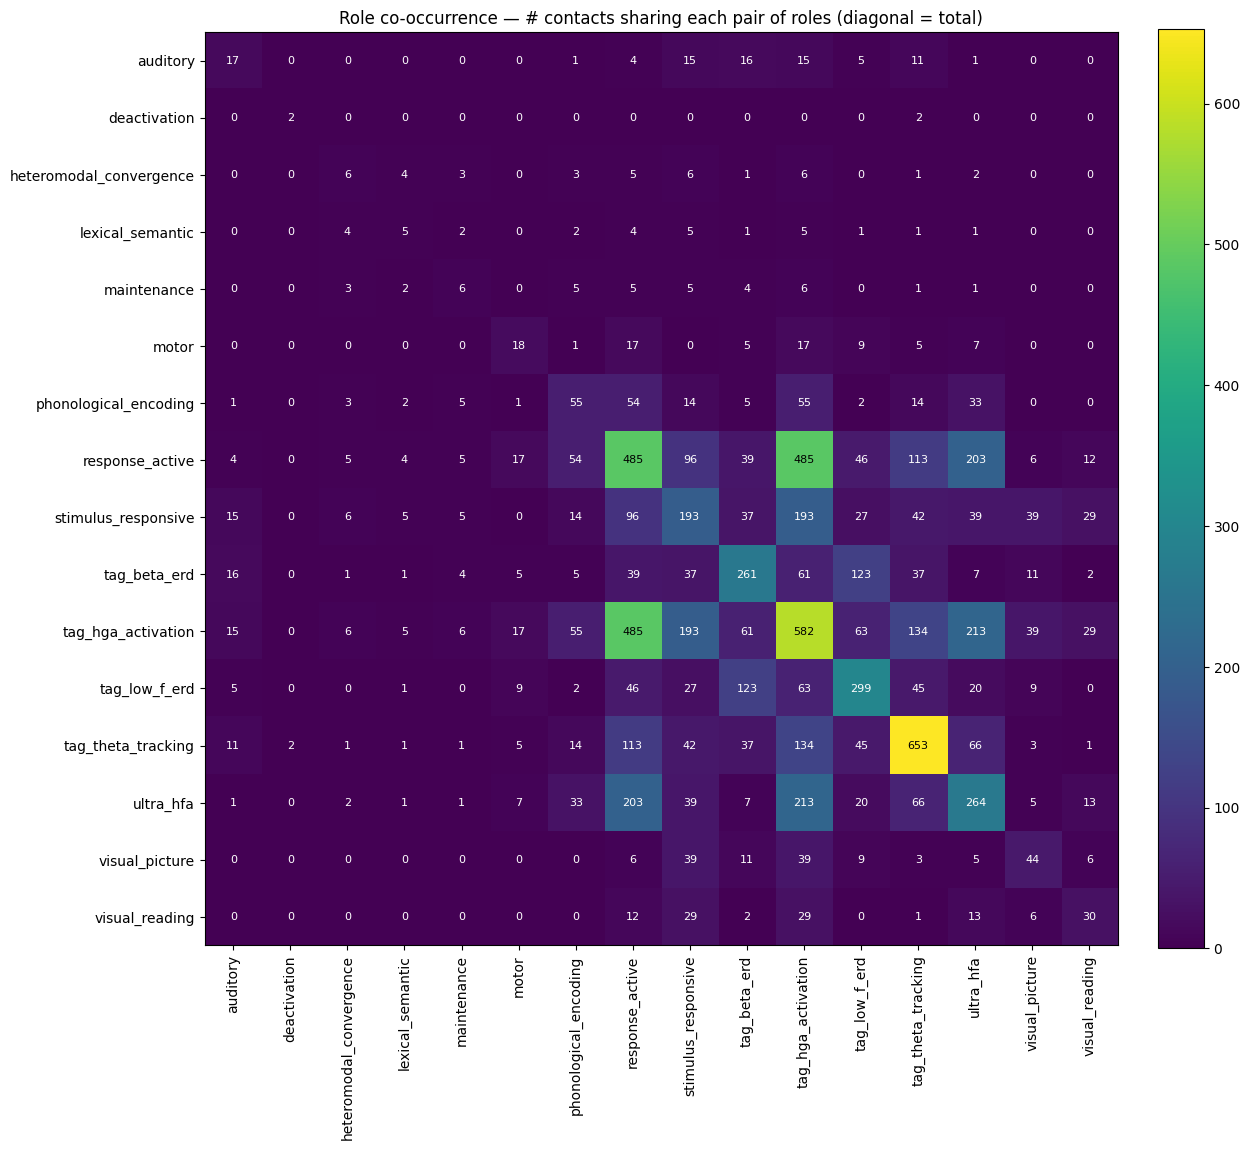

In [13]:
import numpy as np, matplotlib.pyplot as plt
M = P.role_membership(df_role)                       # one row/contact, bool col per matched role
role_cols = [c for c in M.columns if c not in ('patient_id', 'contact_norm')]
B = M[role_cols].to_numpy().astype(int)
C = B.T @ B                                          # co-occurrence counts; diagonal = n_matched
fig, ax = plt.subplots(figsize=(0.6 * len(role_cols) + 3, 0.6 * len(role_cols) + 3))
im = ax.imshow(C, cmap='viridis')
ax.set_xticks(range(len(role_cols))); ax.set_xticklabels(role_cols, rotation=90)
ax.set_yticks(range(len(role_cols))); ax.set_yticklabels(role_cols)
vmax = int(C.max()) if C.size else 1
for i in range(len(role_cols)):
    for j in range(len(role_cols)):
        ax.text(j, i, int(C[i, j]), ha='center', va='center', fontsize=8,
                color='white' if C[i, j] < vmax * 0.6 else 'black')
ax.set_title('Role co-occurrence — # contacts sharing each pair of roles (diagonal = total)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


## 4 — Export for the POOL web page
Writes `contacts_pool.csv` (xyz + role + colour) + `pool_index.json` to the **stable**
`outputs/pooling/pool_web/` path that `web/pool.html` (Niivue, in your `lorafanda.github.io`
repo) reads via raw-GitHub. Reuses the MOBA fsaverage meshes. **Commit + push** that folder so
the page can fetch it.


In [ ]:
coords = P.load_coords()
# df_meta carries each contact's ERSP file_path per condition -> pool_samples.json
# so pool.html can show the selected pool's ERSPs (samples strip).
web = P.export_pool_web(df_role, coords, P.OUTPUTS_ROOT / 'pool_web', grid=GRID, df_meta=df_meta)
print('POOL web data ->', web)
# per-role info cards (description + box/gaussian template on a representative ERSP) for the web info panel
P.export_role_info(INPUT_DIR, df_role, P.OUTPUTS_ROOT / 'pool_web', grid=GRID)
# downsampled raw-ERSP cube for the poolv2 interactive role designer (fraction-above-threshold, client-side)
P.export_pool_cube(INPUT_DIR, df_contacts, P.OUTPUTS_ROOT / 'pool_cube')


[lf_pool] POOL samples -> pool_samples.json  (2644 contacts)
[lf_pool] POOL web export -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\pool_web  (2644 contacts)
POOL web data -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\pool_web
[lf_pool] role_info -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\pool_web\role_info.json  (17 roles, 10 cards)
